# **((Exploratory Data Analysis))**|

## Objectives

* "Here, we will view our dataset and plot the class distribution, data distribution, the average images, average variability, and both image montages for malignant and benign labels"
  
* Hypothesis 1: The dataset is balanced between malignant and non-malignant classes.
  
* Hypothesis 2: Hypothesis 2: There is a visual difference between malignant and non-malignant average images Validation process: Compute and display the average image for each class. If they appear visually different(like in colour or shape).

## Inputs

* inputs/skin_cancer_dataset/melanoma_cancer_dataset/test
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/train
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/validation

## Outputs

* outputs/v1/labels_distribution.png
* outputs/v1/total_images_per_label
* outputs/v1/image_sizes.pkl
* outputs/v1/avg_var_benign.png
* outputs/v1/avg_var_malignant.png
* outputs/v1/benign_vs_malignant_difference.png
* outputs/v1/malignant_montage.png
* outputs/v1/benign_montage.png
* outputs/v1/image_dimensions_distribution.png

## Additional Comments

No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector'

---

# Data Directories

## Input Directories

Set train, validation, and test set paths so machine knows where the data is

In [5]:
my_data_dir = 'inputs/skin_cancer_dataset/melanoma_cancer_dataset'
train_path = my_data_dir + '/train'
validation_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so the machine knows where to place the outputs

In [6]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print("outputs directory already exists")
    pass
else:
    os.makedirs(file_path)
    print("outputs directory created")

outputs directory already exists


# Set Label Names

Setting label names to know difference

In [7]:
labels = os.listdir(train_path)
print(f"Labels: {labels}")

Labels: ['malignant', 'benign']


# Plotting Class Distribution

We will see how our classes(or labels) are distributed.

train set has 3573 images for label malignant
train set has 3849 images for label benign
validation set has 510 images for label malignant
validation set has 550 images for label benign
test set has 1022 images for label malignant
test set has 1101 images for label benign




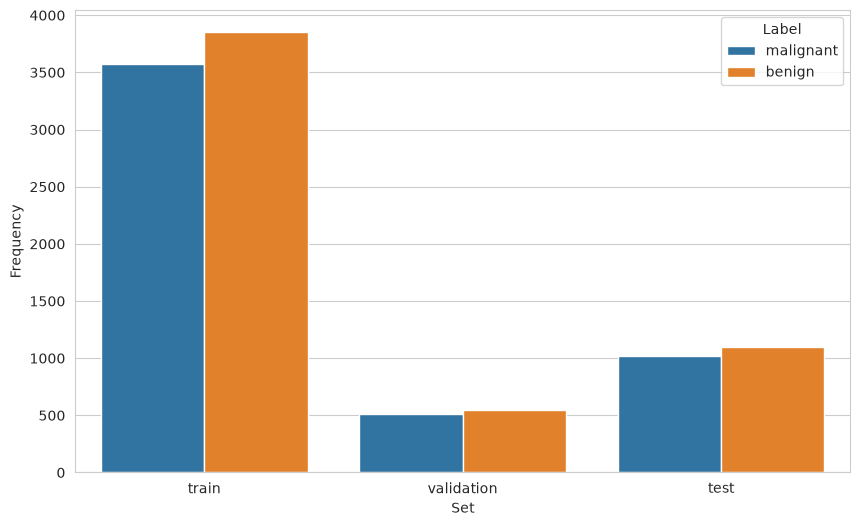

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

data = {
    'Set': [],
    'Label': [],
    'Frequency': []
}

# Number or rows
folders = ['train', 'validation', 'test']

for folder in folders:
    for label in labels:
        row = {
            'Set': folder,
            'Label': label,
            'Frequency': int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        }
        for key, value in row.items():
            data[key].append(value)
        print(
            f"{folder} set has {row['Frequency']} images for label {label}"
        )

#convert to a dataframe
df_freq = pd.DataFrame(data)

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x='Set', y='Frequency', hue='Label', data=df_freq)
plt.savefig(f'{file_path}/labels_distribution.png', bbox_inches = 'tight', dpi=150)

plt.show()

As we can see, there is less than a 10% difference in the number of images for each label(or class). Thus, proving that the dataset is balanced between classes

# Plotting Distribution of data

Now instead of looking at how many images each set has, we will look at how many images in each label there are in total

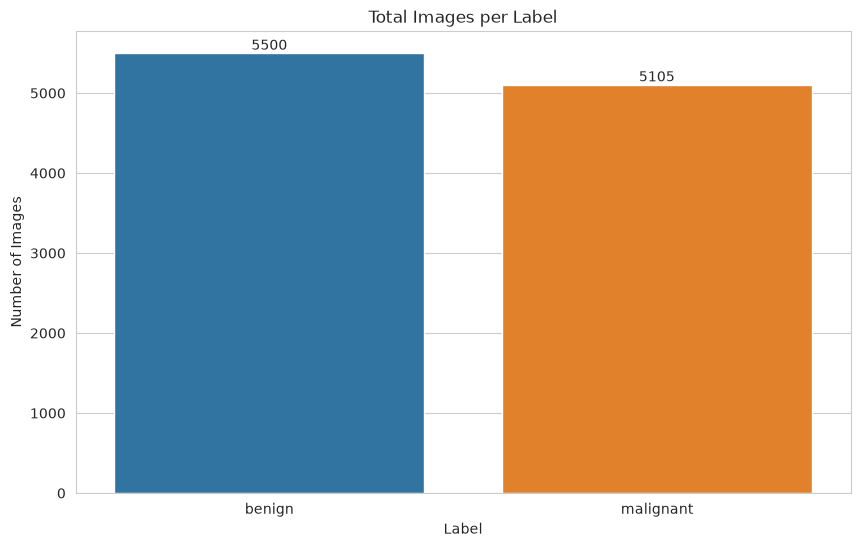

In [11]:
label_totals = df_freq.groupby('Label', as_index=False)['Frequency'].sum()

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Label', y='Frequency', data=label_totals, hue='Label', legend=False)
ax.set_title('Total Images per Label')
ax.set_xlabel('Label')
ax.set_ylabel('Number of Images')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.savefig(f'{file_path}/total_images_per_label.png', bbox_inches='tight', dpi=150)
plt.show()

# Image Shape

See the average image size in the train set

Average image size: 300.00 x 300.00 pixels (width x height)


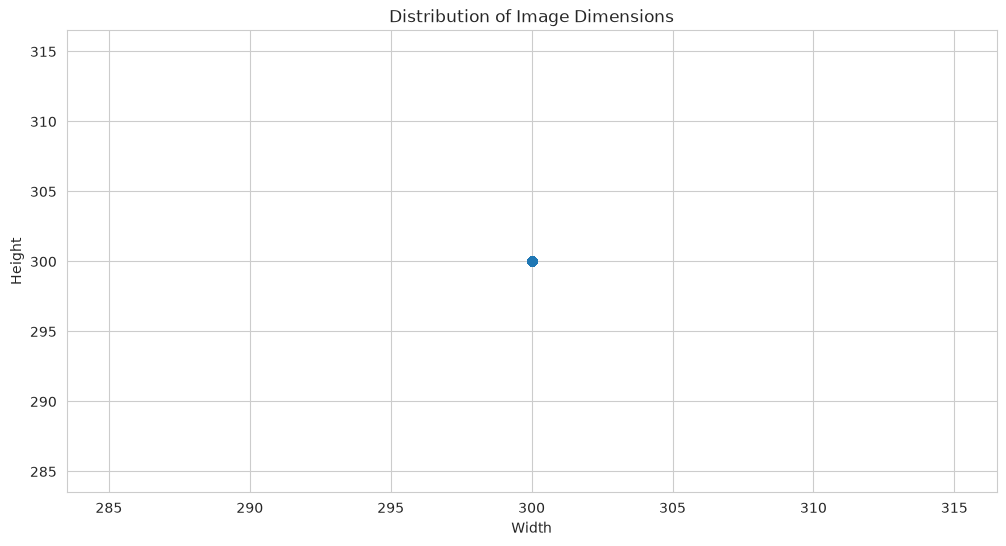

In [12]:
from matplotlib.image import imread
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dim1 = []
dim2 = []

for label in labels:
    for image_filename in os.listdir(train_path + '/' + label):
        img = imread(train_path + '/' + label + '/' + image_filename)
        d1, d2, _ = img.shape
        dim1.append(d1)
        dim2.append(d2)

print(f'Average image size: {np.mean(dim2):.2f} x {np.mean(dim1):.2f} pixels (width x height)')
    
sns.set_style('whitegrid')
plt.figure(figsize=(12,6))
plt.title('Distribution of Image Dimensions')
plt.xlabel('Width')
plt.ylabel('Height')
plt.scatter(dim1, dim2)
plt.savefig(f'{file_path}/image_dimensions_distribution.png', bbox_inches='tight', dpi=150)

In [8]:
image_sizes = set()

for label in labels:
    for image_filename in os.listdir(train_path + '/' + label):
        image = imread(train_path + '/' + label + '/' + image_filename)
        image_sizes.add(image.shape[:2])

print(f'Number of unique image sizes: {len(image_sizes)}')
print(f'Image sizes found (height, width): {sorted(image_sizes)}')

if len(image_sizes) == 1:
    print('All training images have the exact same size.')
else:
    print('Training images do not all have the same size.')

NameError: name 'imread' is not defined

All training images have the same size

In [15]:
image_size = (300, 300)  # no need to resize images as they are already of the same size

Now we save the image size

In [16]:
import joblib
joblib.dump(value=image_sizes, filename=f"{file_path}/image_sizes.pkl")

['outputs/v1/image_sizes.pkl']

# Colour Format

Here, we will check the colour format and see if it needs any changing later on in the feature engineering section

In [18]:
from pathlib import Path
from PIL import Image


def convert_images_to_rgb(data_dir):
    supported_extensions = {'.jpg', '.jpeg', '.png'}
    converted_files = []

    for file_path in Path(data_dir).rglob('*'):
        if not file_path.is_file() or file_path.suffix.lower() not in supported_extensions:
            continue

        with Image.open(file_path) as image:
            if image.mode != 'RGB':
                image_format = image.format
                rgb_image = image.convert('RGB')
                rgb_image.save(file_path, format=image_format)
                converted_files.append(str(file_path))

    return converted_files


converted_files = convert_images_to_rgb('inputs/skin_cancer_dataset/melanoma_cancer_dataset')
print(f'Converted {len(converted_files)} images to RGB.')

Converted 0 images to RGB.


Since no images were converted to RGB, there is no need to do something about it in feature engineering

# Average and Variability of images per Label

In [23]:
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import os

def load_image_as_array(data_dir, new_size=(224, 224), n_images_per_label=30):
    X_list = []
    y_list = []

    labels = sorted(
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    )

    for label in labels:
        label_dir = os.path.join(data_dir, label)
        count = 0

        for image_filename in sorted(os.listdir(label_dir)):
            if count >= n_images_per_label:
                break

            img_path = os.path.join(label_dir, image_filename)

            if not os.path.isfile(img_path):
                continue

            img = keras_image.load_img(img_path, target_size=new_size, color_mode="rgb")
            arr = keras_image.img_to_array(img)

            # Normalize if pixel values are in 0..255
            if arr.max() > 1:
                arr = arr / 255.0

            X_list.append(arr)
            y_list.append(label)
            count += 1

    X = np.stack(X_list) if X_list else np.empty((0, *new_size, 3), dtype=np.float32)
    y = np.array(y_list, dtype=object)

    return X, y

Load image shape and labels in array

In [24]:
new_size = next(iter(image_sizes))   

X, y = load_image_as_array(
    data_dir=train_path,
    new_size=new_size,
    n_images_per_label=30
)

print(X.shape, y.shape)

(60, 300, 300, 3) (60,)


Plot and save average and variability of images per label

In [26]:
def plot_mean_variability_per_labels(X, y, figsize=(12,5), save_image=False):
  """
   The pseudo code for the function is:
  * Loop in all labels
  * Subset an array for given label
  * Calculate mean and standard deviation
  * Create a figure displaying mean and variability of images
  * Save image

  """

  for label_to_display in np.unique(y):
    sns.set_style("white")

    y = y.reshape(-1,1,1)
    boolean_mask = np.any(y==label_to_display,axis=1).reshape(-1)
    arr = X[boolean_mask]

    avg_img = np.mean(arr, axis = 0)
    std_img = np.std(arr, axis = 0)
    print(f"==== Label {label_to_display} ====")
    print(f"Image Shape: {avg_img.shape}")
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=figsize)
    axes[0].set_title(f"Average Image for label {label_to_display}")
    axes[0].imshow(avg_img, cmap='gray')
    axes[1].set_title(f"Variability image for label {label_to_display}")
    axes[1].imshow(std_img, cmap='gray')

    if save_image:
      plt.savefig(f"{file_path}/avg_var_{label_to_display}.png", bbox_inches='tight', dpi=150)
    else:
      plt.tight_layout()
      plt.show()
      print("\n")

==== Label benign ====
Image Shape: (300, 300, 3)
==== Label malignant ====
Image Shape: (300, 300, 3)


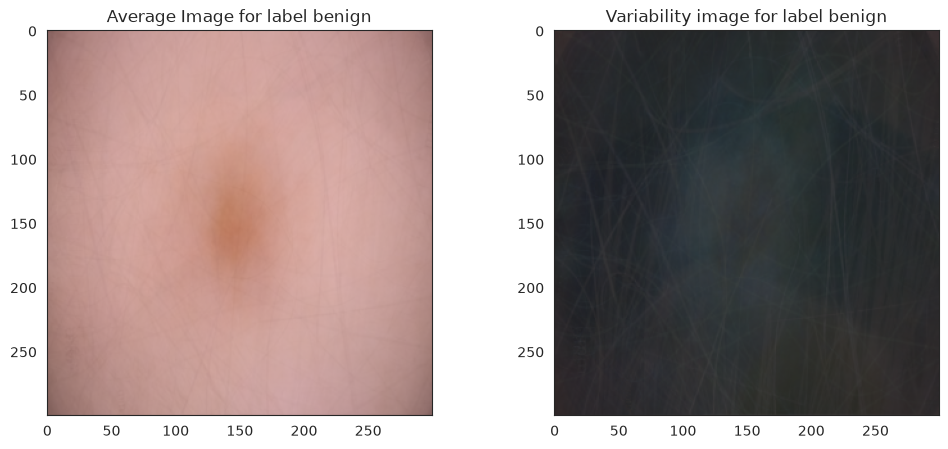

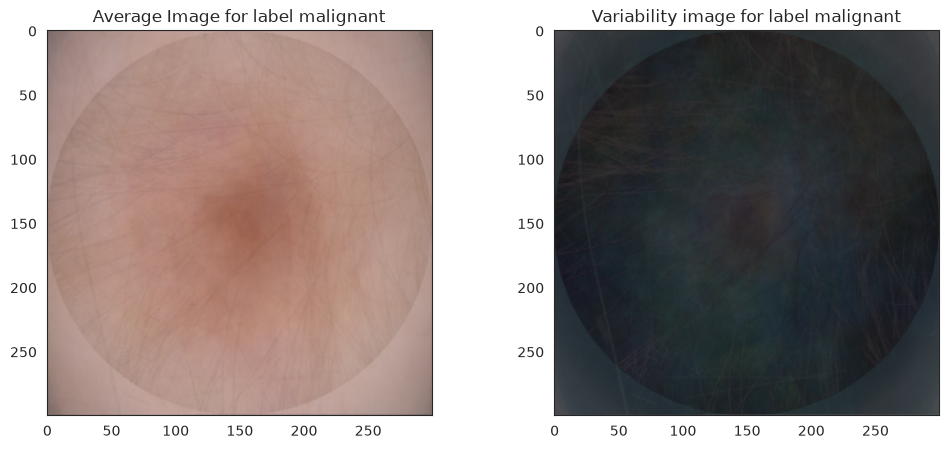

In [28]:
plot_mean_variability_per_labels(X, y, save_image=True)

Looking at these images, one would not be able to intuitively tell whether one is benign or malignant

# Difference between average benign and average malignant skin lesion images

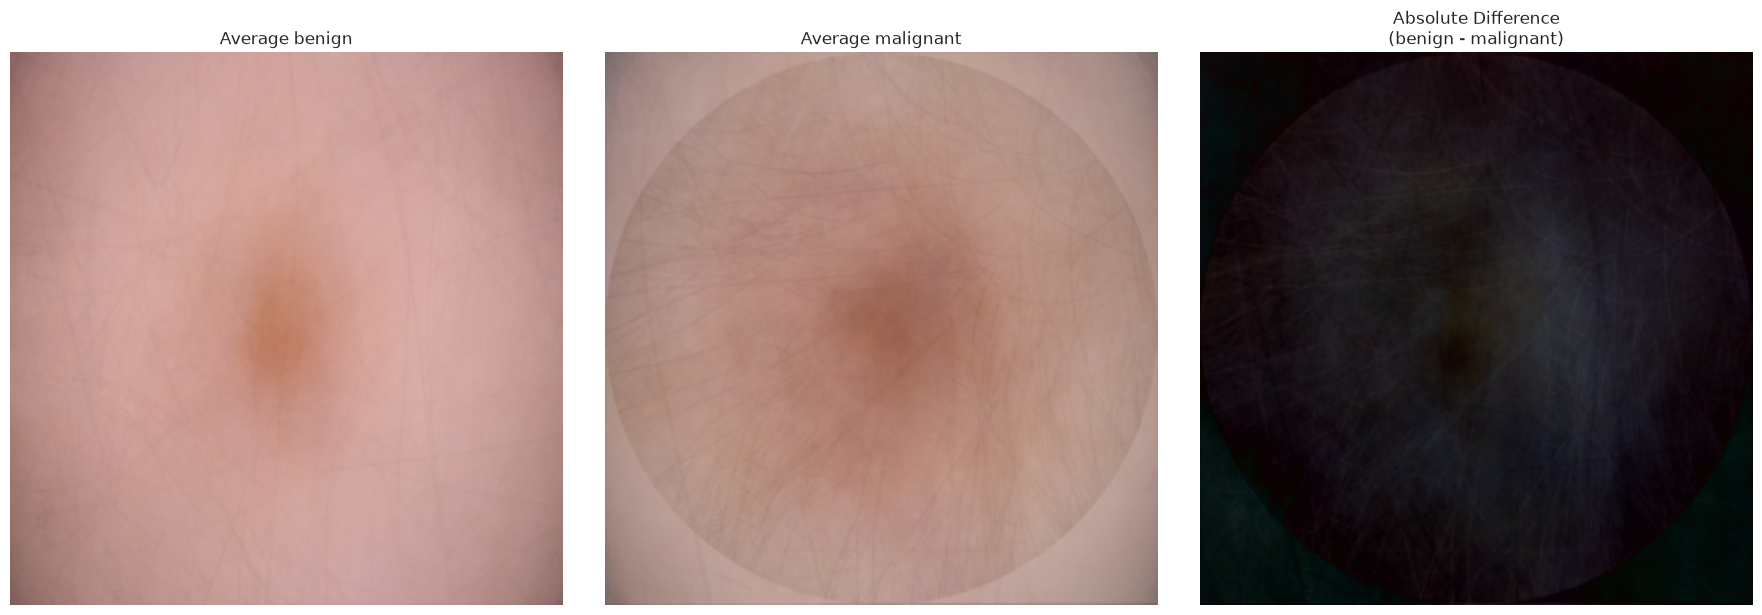

In [31]:
y_str = np.asarray(y, dtype=str)
label_names = np.unique(y_str)

# Try to find labels that match "benign" and "malignant"
benign_candidates = [label for label in label_names if "benign" in label.lower()]
malignant_candidates = [
    label for label in label_names
    if ("malign" in label.lower()) or ("melanoma" in label.lower()) or ("cancer" in label.lower())
]

if not benign_candidates:
    benign_candidates = [str(label_names[0])]

if not malignant_candidates:
    if len(label_names) > 1:
        malignant_candidates = [str(label_names[1])]
    else:
        malignant_candidates = [str(label_names[0])]

benign_label = benign_candidates[0]
malignant_label = malignant_candidates[0]

benign_mask = (y_str == benign_label)
malignant_mask = (y_str == malignant_label)

avg_benign = X[benign_mask].mean(axis=0)
avg_malignant = X[malignant_mask].mean(axis=0)

# Difference map: positive values mean more in benign, negative mean more in malignant
difference_map = avg_benign - avg_malignant
abs_difference_map = np.abs(difference_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(avg_benign)
axes[0].set_title(f"Average {benign_label}")
axes[0].axis("off")

axes[1].imshow(avg_malignant)
axes[1].set_title(f"Average {malignant_label}")
axes[1].axis("off")

axes[2].imshow(abs_difference_map, cmap="coolwarm")
axes[2].set_title(f"Absolute Difference\n({benign_label} - {malignant_label})")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f"outputs/v1/benign_vs_malignant_difference.png", bbox_inches="tight", dpi=150)
plt.show()

Looking at these images, you cant really tell intuitively if there is a difference or not

# Image montage

Here we will create two image montages. One for malignant and one for benign

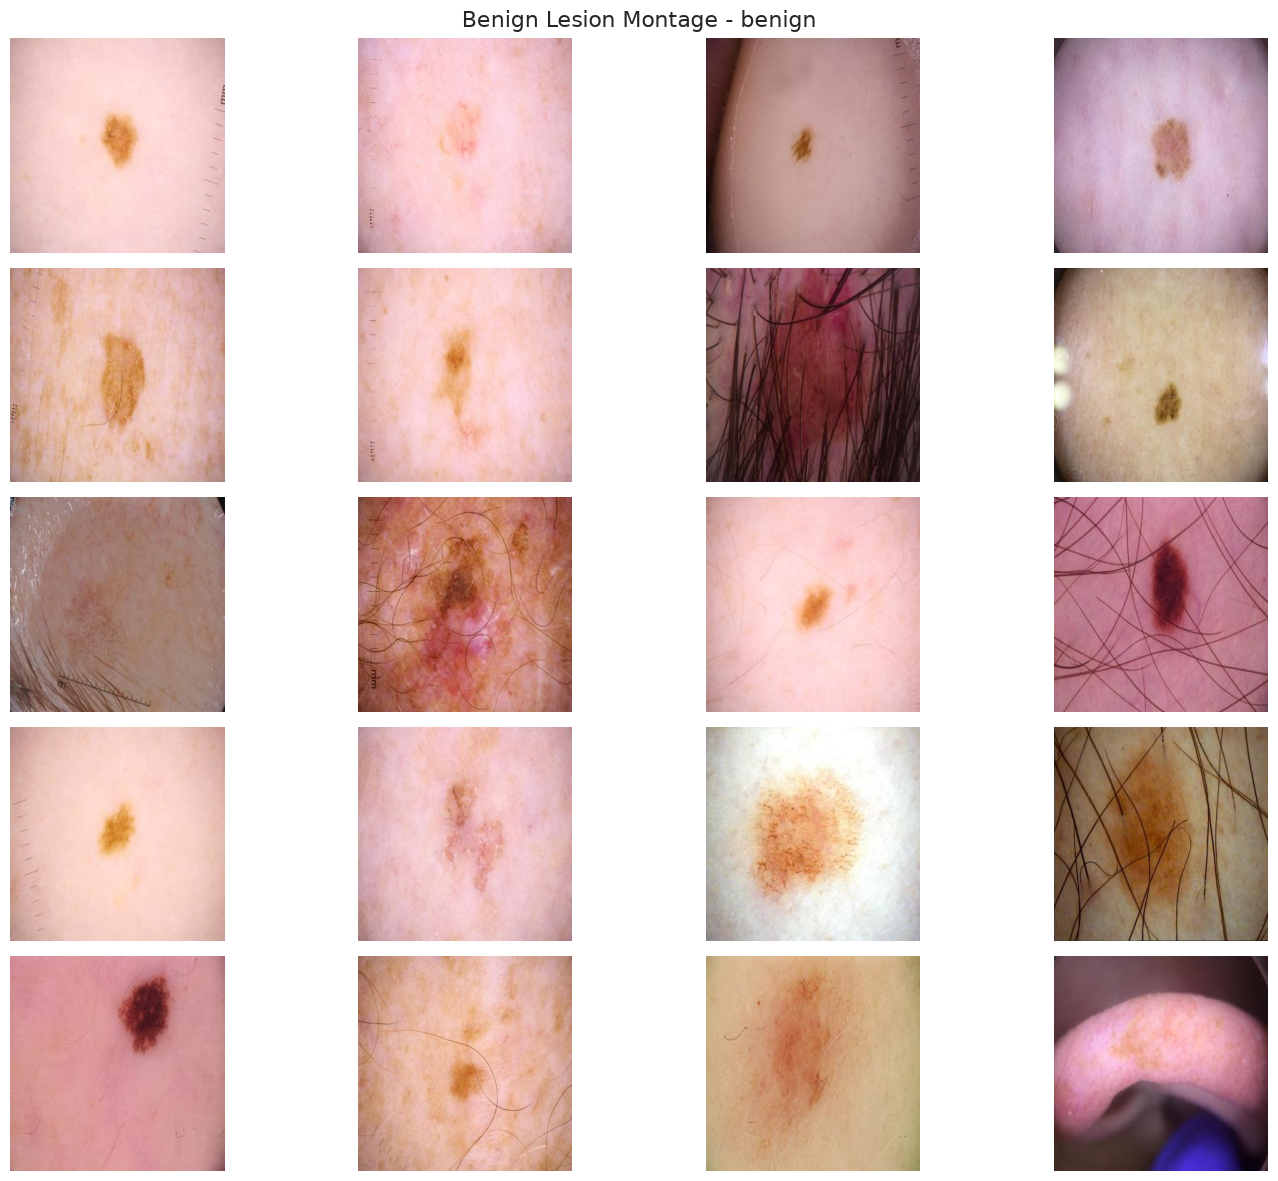

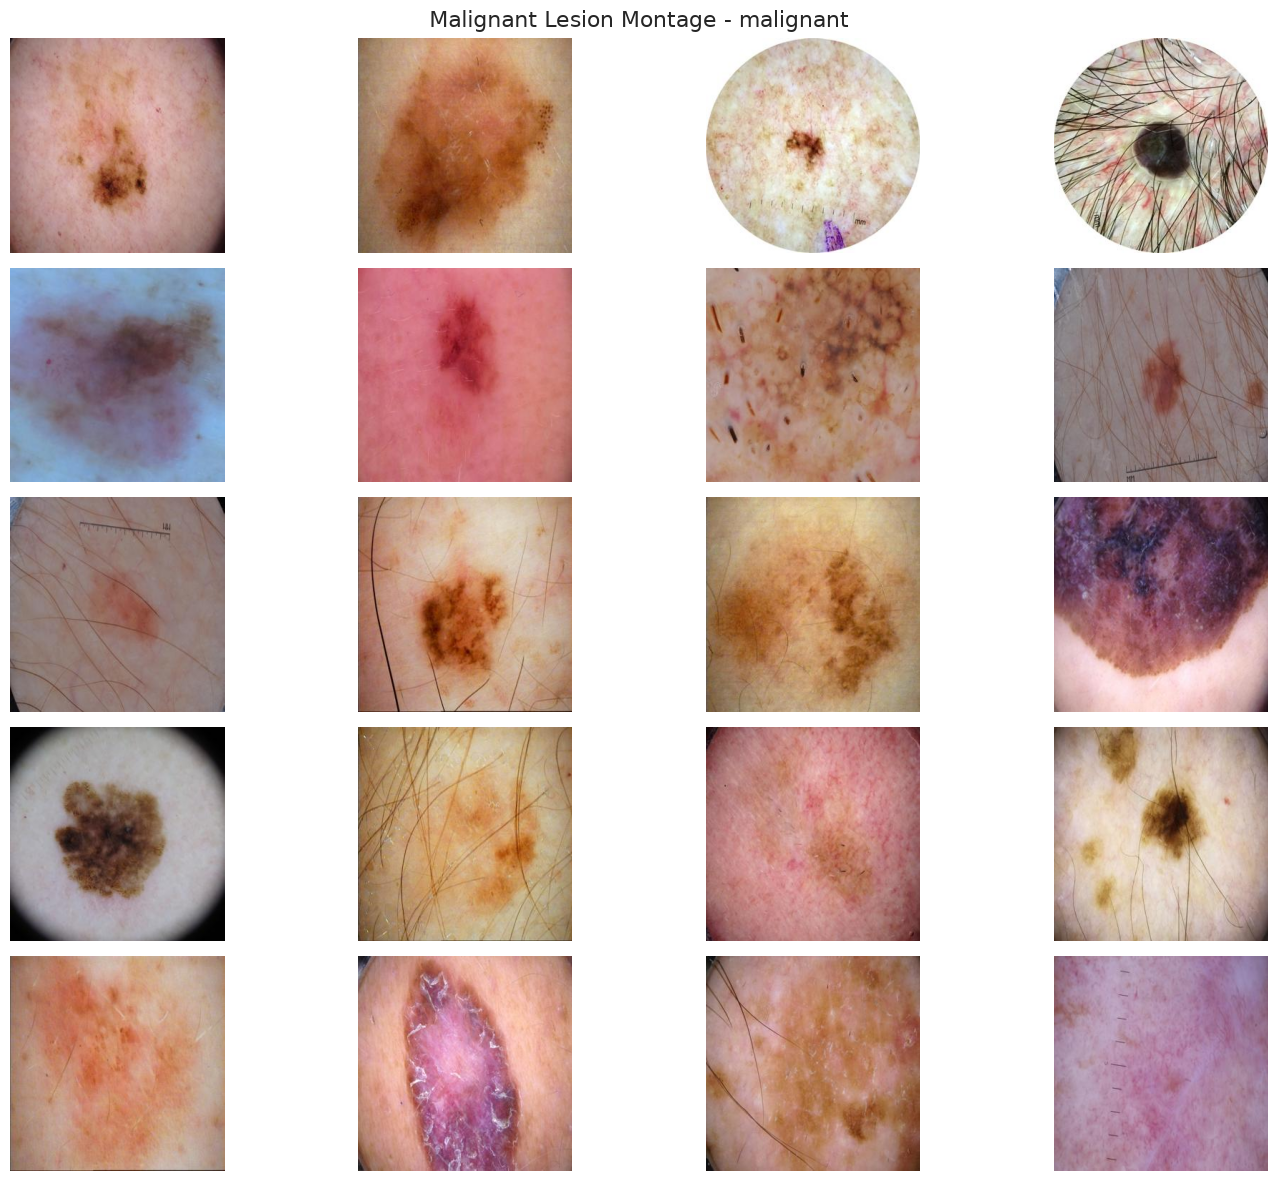

In [32]:
y_str = np.asarray(y, dtype=str)
label_names = np.unique(y_str)

benign_candidates = [label for label in label_names if "benign" in label.lower()]
malignant_candidates = [
    label for label in label_names
    if ("malign" in label.lower()) or ("melanoma" in label.lower()) or ("cancer" in label.lower())
]

if not benign_candidates:
    benign_candidates = [str(label_names[0])]
if not malignant_candidates:
    if len(label_names) > 1:
        malignant_candidates = [str(label_names[1])]
    else:
        malignant_candidates = [str(label_names[0])]

benign_label = benign_candidates[0]
malignant_label = malignant_candidates[0]

benign_images = X[y_str == benign_label][:30]
malignant_images = X[y_str == malignant_label][:30]

def create_montage(images, title, rows=5, cols=4):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for ax in axes.flat:
        ax.axis("off")

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i]
            # Ensure values are in range 0..1 for display
            img = np.clip(img, 0, 1)
            ax.imshow(img)
        else:
            ax.axis("off")

    plt.tight_layout()
    return fig

benign_fig = create_montage(benign_images, f"Benign Lesion Montage - {benign_label}")
malignant_fig = create_montage(malignant_images, f"Malignant Lesion Montage - {malignant_label}")

benign_fig.savefig(f"{file_path}/benign_montage.png", bbox_inches="tight", dpi=150)
malignant_fig.savefig(f"{file_path}/malignant_montage.png", bbox_inches="tight", dpi=150)

plt.show()

Here, you can see that the malignant skin leasions are larger and more expressive when it comes to colours, while the benign skin lesions are smaller and have less expressive colours

---

# Conclusions and Next Steps

We have concluded hypothesis 1(The dataset is balanced between malignant and benign classes/labels. Vypothesis was validated by having less than 10% difference)

We have concluded Hypothesis 2(there is a difference between malignant and benign skin lesions when looking at them individually, however, on averae there is no way to be 100% certain that one is malignant or not).

Next, we will develop the CNN(ML Model) to predict benigs malignant skin lesions

Lastly, do the following commands in the terminal to save the files

git add .

git commit -m "message you want to add"

git push